# Finetuning our detection model


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, datasets, models
from pathlib import Path
import random
from torch.utils.data import random_split, DataLoader
from transformers import AutoImageProcessor, AutoModelForObjectDetection
from PIL import Image
import copy
import time

In [11]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using GPU:", torch.cuda.get_device_name(0))
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon GPU")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

device = get_device()

Using GPU: NVIDIA GeForce RTX 4060


In [12]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
torch.backends.cudnn.deterministic = True
# benchmark=False is required when deterministic=True; enabling both causes non-deterministic behaviour
torch.backends.cudnn.benchmark = False


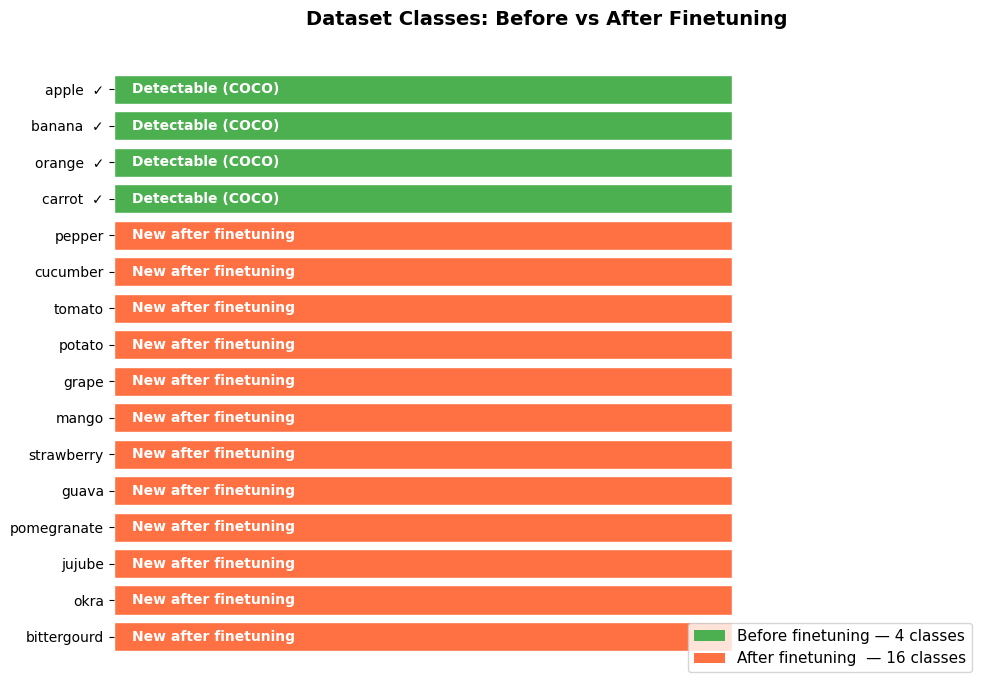

In [13]:
from matplotlib.patches import Patch

# Classes detectable by base DETR (trained on COCO)
before = {"apple", "banana", "orange", "carrot"}

# All unique item classes in our dataset
all_classes = [
    "apple", "banana", "orange", "carrot",       # already in COCO
    "pepper", "cucumber", "tomato", "potato",    # new after finetuning
    "grape", "mango", "strawberry", "guava",
    "pomegranate", "jujube", "okra", "bittergourd",
]

colors = ["#4CAF50" if c in before else "#FF7043" for c in all_classes]
labels = [f"{c}  ✓" if c in before else c for c in all_classes]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(labels[::-1], [1] * len(all_classes), color=colors[::-1], edgecolor="white")

ax.set_xlim(0, 1.4)
ax.set_xticks([])
ax.set_xlabel("")
ax.set_title("Dataset Classes: Before vs After Finetuning", fontsize=14, fontweight="bold", pad=15)

for bar, label in zip(bars, labels[::-1]):
    status = "Detectable (COCO)" if label.endswith("✓") else "New after finetuning"
    ax.text(0.03, bar.get_y() + bar.get_height() / 2, status,
            va="center", ha="left", fontsize=10, color="white", fontweight="bold")

ax.legend(handles=[
    Patch(facecolor="#4CAF50", label=f"Before finetuning — {len(before)} classes"),
    Patch(facecolor="#FF7043", label=f"After finetuning  — {len(all_classes)} classes"),
], fontsize=11, loc="lower right")

ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
plt.tight_layout()
plt.savefig("dataset_coverage.png", dpi=150)
plt.show()

# Dataset and DataLoaders
Train and val are loaded from **separate folders** so each gets its own transform — no shared dataset object.

**Train transforms**
* `RandomResizedCrop(224)` — random scale + crop to 224×224, forces the model to be scale-invariant
* `RandomHorizontalFlip` — horizontal flip augmentation
* `ColorJitter` — random brightness/contrast/saturation shifts
* Normalize with ImageNet mean/std

**Val transforms** (no augmentation — deterministic)
* `Resize(256)` → `CenterCrop(224)` — standard ImageNet eval protocol
* Normalize with ImageNet mean/std


In [14]:
IMAGNET_MEAN = [0.485, 0.456, 0.406]
IMAGNET_STD = [0.229, 0.224, 0.225]

# RandomResizedCrop ensures a square 224x224 output regardless of input aspect ratio,
# and provides scale/crop augmentation that improves generalization.
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGNET_MEAN, std=IMAGNET_STD)
])

# Resize(256) + CenterCrop(224) is the standard ImageNet evaluation protocol;
# plain Resize(224) would only scale the short edge and leave a non-square tensor.
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGNET_MEAN, std=IMAGNET_STD)
])


In [ ]:
# Separate ImageFolder per split — each gets its own transform object.
# This avoids the random_split pitfall where both subsets share one transform
# and val images get augmented (random crops/flips) during evaluation.
train_dataset = datasets.ImageFolder(root="./data/train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(root="./data/val",   transform=val_transforms)

# Guard: both folders must contain identical class sets
assert train_dataset.classes == val_dataset.classes, (
    f"Class mismatch between train and val folders."
    f"Train: {train_dataset.classes}"
    f"Val: {val_dataset.classes}"
)

num_classes = len(train_dataset.classes)
print(f"Train : {len(train_dataset):,} images")
print(f"Val   : {len(val_dataset):,} images")
print(f"Classes ({num_classes}): {train_dataset.classes}")


Total samples: 47323, Train: 37859, Val: 9464


In [16]:
BATCH_SIZE = 64
pin = device.type == "cuda"

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=pin, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=pin, persistent_workers=True
)


In [17]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    # Multiply by 100 so accuracy is expressed as a percentage (e.g. 95.42)
    epoch_acc = correct / total * 100
    return epoch_loss, epoch_acc


In [18]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    # Multiply by 100 so accuracy is expressed as a percentage (e.g. 95.42)
    epoch_acc = correct / total * 100
    return epoch_loss, epoch_acc


In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, scheduler=None, model_name="Model"):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    print(f"\n {"="*60}")
    print(f"Training {model_name}")
    print(f"{"="*60}")

    start_time = time.time()
    for epoch in range(num_epochs):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        if scheduler:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.1f}s")
    total_time = time.time() - start_time
    print(f"\nTraining complete in {total_time/60:.1f} minutes")
    print(f"Best validation accuracy: {best_acc:.2f}%")

    model.load_state_dict(best_model_wts)
    return model, history

In [20]:
def plot_curves(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

In [21]:
def show_predictions(model, dataloader, class_names, device, num_images=8):
    """
    Display sample images with predicted and true labels.
    """
    model.eval()
    images_shown = 0
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten() # Flatten to easily index subplots
    
    # Denormalize for display
    mean = torch.tensor(IMAGNET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGNET_STD).view(3, 1, 1)
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                
                # Denormalize image
                img = inputs[i].cpu() * std + mean
                img = img.permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)
                
                true_label = class_names[labels[i]]
                pred_label = class_names[predicted[i]]
                color = 'green' if true_label == pred_label else 'red'
                
                axes[images_shown].imshow(img)
                axes[images_shown].set_title(f'True: {true_label}\nPred: {pred_label}', 
                                             color=color, fontsize=10)
                axes[images_shown].axis('off')
                images_shown += 1
            
            if images_shown >= num_images:
                break
    
    plt.tight_layout()
    plt.show()

In [22]:
feature_extractor = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
print("Original ResNet-50 loaded with ImageNet weights.")
print(feature_extractor.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Biraj/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:24<00:00, 4.22MB/s]


Original ResNet-50 loaded with ImageNet weights.
Linear(in_features=2048, out_features=1000, bias=True)


In [ ]:
# Unfreeze all layers for full fine-tuning (backbone + head).
# All parameters will be updated by the optimizer.
for param in feature_extractor.parameters():
    param.requires_grad = True

# Replace the final classifier to match the actual number of dataset classes.
# Using len(dataset.classes) avoids a hard-coded count that would mismatch at runtime.
num_features = feature_extractor.fc.in_features
feature_extractor.fc = torch.nn.Linear(num_features, num_classes)
print(f"New final layer: Linear(in_features={num_features}, out_features={num_classes})")


In [ ]:
feature_extractor = feature_extractor.to(device)

total_params = sum(p.numel() for p in feature_extractor.parameters())
trainable_params = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params:.2%})")


In [ ]:
criterion = torch.nn.CrossEntropyLoss()

# AdamW decouples weight decay from the gradient update, which reduces overfitting
# when fine-tuning all layers. Use a lower LR (1e-4) than training from scratch
# to preserve the pretrained ImageNet features.
optimizer = optim.AdamW(feature_extractor.parameters(), lr=1e-4, weight_decay=1e-4)

# CosineAnnealingLR smoothly reduces the LR from its initial value to near-zero
# over T_max epochs, which helps the model converge without a hard LR drop.
FEATURE_EXTRACTOR_EPOCHS = 10
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FEATURE_EXTRACTOR_EPOCHS)

feature_extractor, history = train_model(
    feature_extractor, train_loader, val_loader,
    criterion, optimizer, device,
    FEATURE_EXTRACTOR_EPOCHS, scheduler=scheduler,
    model_name="ResNet-50 Finetuning"
)
plot_curves(history, title="ResNet-50 Finetuning")


In [ ]:
import json as _json
from pathlib import Path

model_dir = Path("./models")
model_dir.mkdir(exist_ok=True)

# Save only the weights — the architecture is rebuilt in detection.py
torch.save(feature_extractor.state_dict(), model_dir / "freshguard_resnet50.pth")

# Save class names in index order so detection.py can map logit index → label
# train_dataset.classes is already sorted alphabetically by ImageFolder
with open(model_dir / "class_names.json", "w") as f:
    _json.dump(train_dataset.classes, f, indent=2)

print(f"Weights  : {model_dir / 'freshguard_resnet50.pth'}")
print(f"Classes  : {model_dir / 'class_names.json'}")
print(f"Num classes saved: {len(train_dataset.classes)}")


# YOLO Detection Finetuning
Finetune `yolo11x.pt` on all 34 Fresh/Rotten produce classes so the detector
can locate **and** classify produce in multi-item scenes without a separate
classifier stage.

**Run `prepare_yolo_dataset.py` once before this cell** — it builds the YOLO
directory structure (image junctions + label files + `dataset.yaml`).


In [ ]:
import importlib, prepare_yolo_dataset
importlib.reload(prepare_yolo_dataset)  # picks up any edits without restarting kernel
prepare_yolo_dataset.prepare()


In [ ]:
from ultralytics import YOLO
from pathlib import Path

yolo_model = YOLO("yolo11x.pt")  # start from COCO-pretrained weights

results = yolo_model.train(
    data=str(Path("./data/yolo/dataset.yaml").resolve()),
    epochs=50,
    imgsz=640,
    batch=16,       # reduce to 8 if GPU runs out of memory
    device=0,       # GPU; change to 'cpu' if no CUDA
    workers=4,
    # freeze=10 freezes the first 10 *layers* (not epochs) for the entire run.
    # For yolo11x, layers 0–9 are the backbone; run yolo_model.info(verbose=True)
    # to confirm the layer count before changing this value.
    freeze=10,
    optimizer="AdamW",
    lr0=1e-4,       # low LR preserves pretrained COCO features
    lrf=0.01,       # cosine decay to lr0 * lrf at the final epoch
    weight_decay=5e-4,
    project="./models",
    name="freshguard_yolo",
    exist_ok=True,
)

best_weights = Path(results.save_dir) / "weights" / "best.pt"
print(f"Best weights saved to: {best_weights}")